# Performance_Analytics

1. Import Libraries

2. Load Data

3. Compute Daily Returns

4. Annualized Return

5. CAGR

6. Sharpe Ratio

7. Sortino Ratio

8. Alpha & Beta

9. Maximum Drawdown

10. Fund Scorecard

11. Benchmark Comparison

12. Top/Bottom Funds

13. Final Insights

1. Import Libraries

2. Load Data

3. Compute Daily Returns

4. Annualized Return

5. CAGR

6. Sharpe Ratio

7. Sortino Ratio

8. Alpha & Beta

9. Maximum Drawdown

10. Fund Scorecard

11. Benchmark Comparison

12. Top/Bottom Funds

13. Final Insights

## Import Libraries

In [50]:
#import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import linregress

plt.style.use("ggplot")

from pathlib import Path

# Set up local paths relative to notebook location
PROJECT_ROOT = Path("..").resolve()
RAW_DATA = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA = PROJECT_ROOT / "data" / "processed"
CHARTS = PROJECT_ROOT / "reports" / "charts"

In [8]:
#Load the data
funds = pd.read_csv("../data/raw/01_fund_master.csv")

nav = pd.read_csv("../data/processed/clean_nav_history.csv")

performance = pd.read_csv("../data/processed/clean_scheme_performance.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [9]:
#date conversion
nav["date"] = pd.to_datetime(nav["date"])

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

In [10]:
#Daily return calculation
#daily_return = NAV_t/NAV_t-1 -1
nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = (
    nav
    .groupby("amfi_code")["nav"]
    .pct_change()
)
#Exporting the cleaned nav history
nav.to_csv(f"{PROCESSED_DATA}/returns_computed.csv",index=False)
print(f"Done Exporting daily Returns")

Done Exporting daily Returns


In [11]:
#Annualized return calculation
#(1+daily_return).prod()^(252/n)-1
annual_return = (
    nav
    .groupby("amfi_code")
    .apply(
        lambda x:
        (
            (1+x["daily_return"]).prod()
        )**(
            252/len(x)
        )-1
    )
)
annual_return = annual_return.reset_index()

annual_return.columns = [
    "amfi_code",
    "annualized_return"
]

annual_return.to_csv(
    f"{PROCESSED_DATA}/annualized_return.csv",
    index=False
)

annual_return.head()

,amfi_code,annualized_return
0,100016,0.025412
1,100025,0.042948
2,100033,0.288994
3,101206,0.226048
4,101207,0.076433


In [12]:
#CAGR calculation
def calculate_cagr(df, years):

    end_date = df["date"].max()

    start_date = end_date - pd.DateOffset(years=years)

    period = df[df["date"] >= start_date]

    if len(period) < 2:
        return np.nan

    start_nav = period.iloc[0]["nav"]

    end_nav = period.iloc[-1]["nav"]

    cagr = (end_nav/start_nav)**(1/years)-1

    return cagr
cagr = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"]==fund
    ]

    cagr.append({

        "amfi_code":fund,

        "cagr_1yr":calculate_cagr(temp,1),

        "cagr_3yr":calculate_cagr(temp,3),

        "cagr_5yr":calculate_cagr(temp,5)

    })
    cagr_report = pd.DataFrame(cagr)
    cagr_report = cagr_report.merge(

    funds[
        ["amfi_code","scheme_name"]
    ],

    on="amfi_code",

    how="left"

)
cols=[
    "cagr_1yr",
    "cagr_3yr",
    "cagr_5yr"
]

for c in cols:

    cagr_report[c]=(
        cagr_report[c]*100
    ).round(2)

cagr_report.to_csv(f"{PROCESSED_DATA}/cagr_report.csv",index=False)
cagr_report.head()
print("Top 10 Funds by 5-Year CAGR")

display(
    cagr_report
    .sort_values("cagr_5yr", ascending=False)
    .head(10)
)


Top 10 Funds by 5-Year CAGR


,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,scheme_name
25,120505,29.60,31.78,28.38,ICICI Pru Midcap Fund - Regular - Growth
21,119598,82.78,26.67,28.03,SBI Small Cap Fund - Regular Plan - Growth
39,149324,65.14,27.00,27.92,DSP Small Cap Fund - Regular - Growth
36,148569,39.75,29.18,27.63,Mirae Asset Tax Saver Fund - Regular - Growth
34,148567,20.36,34.00,26.80,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,26.66,29.58,26.74,Kotak Flexicap Fund - Regular - Growth
2,100033,53.23,32.44,26.07,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
38,149323,21.48,26.87,25.61,DSP Midcap Fund - Regular - Growth
16,119094,22.26,35.11,24.45,Axis Midcap Fund - Regular - Growth
19,119551,60.44,30.46,22.38,SBI Bluechip Fund - Regular Plan - Growth


In [13]:
#sharpe ratio calculation
rf = 0.065

sharpe = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ]

    returns = temp["daily_return"].dropna()

    annual_return = returns.mean()*252

    annual_volatility = returns.std()*np.sqrt(252)

    sharpe_ratio = (
        annual_return-rf
    )/annual_volatility

    sharpe.append({

        "amfi_code":fund,

        "annual_return":annual_return,

        "annual_volatility":annual_volatility,

        "sharpe_ratio":sharpe_ratio

    })


sharpe_values = pd.DataFrame(sharpe)
sharpe_values = sharpe_values.merge(

    funds[
        ["amfi_code","scheme_name"]
    ],

    on="amfi_code",

    how="left"

)
cols = [
    "annual_return",
    "annual_volatility",
    "sharpe_ratio"
]

for c in cols:

    sharpe_values[c] = sharpe_values[c].round(4)

sharpe_values.to_csv(f"{PROCESSED_DATA}/sharpe_values.csv",index=False)
sharpe_values.head()

print("Top 10 Funds by Sharpe Ratio")

display(
    sharpe_values
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(10)
)

Top 10 Funds by Sharpe Ratio


,amfi_code,annual_return,annual_volatility,sharpe_ratio,scheme_name
34,148567,0.2706,0.1419,1.4483,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,0.2726,0.1589,1.3067,Kotak Flexicap Fund - Regular - Growth
36,148569,0.2833,0.1767,1.2349,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,0.2310,0.1374,1.2083,SBI Bluechip Fund - Regular Plan - Growth
25,120505,0.2927,0.1929,1.1801,ICICI Pru Midcap Fund - Regular - Growth
38,149323,0.2659,0.1775,1.1321,DSP Midcap Fund - Regular - Growth
2,100033,0.2721,0.1894,1.0937,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
9,118632,0.2180,0.1415,1.0817,Nippon India Large Cap Fund - Regular - Growth
3,101206,0.2146,0.1457,1.0272,ABSL Frontline Equity Fund - Regular - Growth
24,120504,0.2124,0.1436,1.0265,ICICI Pru Bluechip Fund - Direct - Growth


In [14]:
#sortino ratio calculation
rf = 0.065

sortino = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ]

    returns = temp["daily_return"].dropna()

    annual_return = returns.mean() * 252

    downside_returns = returns[
        returns < 0
    ]

    downside_std = downside_returns.std() * np.sqrt(252)

    sortino_ratio = (
        annual_return - rf
    ) / downside_std

    sortino.append({

        "amfi_code": fund,

        "annual_return": annual_return,

        "downside_std": downside_std,

        "sortino_ratio": sortino_ratio

    })

sortino_values = pd.DataFrame(sortino)
sortino_values = sortino_values.merge(

    funds[
        ["amfi_code", "scheme_name"]
    ],

    on="amfi_code",

    how="left"

)
cols = [
    "annual_return",
    "downside_std",
    "sortino_ratio"
]

for c in cols:

    sortino_values[c] = (
        sortino_values[c]
        .round(4)
    )

sortino_values.to_csv(f"{PROCESSED_DATA}/sortino_values.csv",index=False)

sortino_values.head()
print("Top 10 Funds by Sortino Ratio")

display(

    sortino_values
    .sort_values(
        "sortino_ratio",
        ascending=False
    )
    .head(10)

)

Top 10 Funds by Sortino Ratio


,amfi_code,annual_return,downside_std,sortino_ratio,scheme_name
34,148567,0.2706,0.0862,2.3856,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,0.2726,0.0878,2.3643,Kotak Flexicap Fund - Regular - Growth
36,148569,0.2833,0.1017,2.1469,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,0.2310,0.0776,2.1403,SBI Bluechip Fund - Regular Plan - Growth
25,120505,0.2927,0.1122,2.0294,ICICI Pru Midcap Fund - Regular - Growth
38,149323,0.2659,0.1071,1.8751,DSP Midcap Fund - Regular - Growth
9,118632,0.2180,0.0827,1.8501,Nippon India Large Cap Fund - Regular - Growth
2,100033,0.2721,0.1132,1.8291,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
24,120504,0.2124,0.0817,1.8053,ICICI Pru Bluechip Fund - Direct - Growth
3,101206,0.2146,0.0832,1.7996,ABSL Frontline Equity Fund - Regular - Growth


In [16]:
#alpha vs beta vs benchmark calculation
benchmark = pd.read_csv(f"{RAW_DATA}/10_benchmark_indices.csv")

print(benchmark.columns.tolist())

benchmark.head()




['date', 'index_name', 'close_value']


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [17]:
#Load benchmark data and filter for Nifty 100 index
benchmark = pd.read_csv(f"{RAW_DATA}/10_benchmark_indices.csv")

benchmark["date"] = pd.to_datetime(benchmark["date"])

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [18]:
# keep only the Nifty 100 index for analysis

benchmark = benchmark[benchmark["index_name"] == "NIFTY100"].copy()
#compute daily returns for the benchmark index

benchmark = benchmark.sort_values("date")

benchmark["benchmark_return"] = (
    benchmark["close_value"]
    .pct_change()
)

benchmark.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [19]:
#prepare fund returns data for alpha and beta calculation
fund_returns = nav[
    [
        "amfi_code",
        "date",
        "daily_return"
    ]
]

from scipy.stats import linregress

alpha_beta = []

#Loop Through Every Fund
for fund in fund_returns["amfi_code"].unique():

    temp = fund_returns[
        fund_returns["amfi_code"] == fund
    ]

    merged = temp.merge(

        benchmark[
            [
                "date",
                "benchmark_return"
            ]
        ],

        on="date",

        how="inner"

    ).dropna()

    if len(merged) < 30:
        continue

    slope, intercept, r_value, p_value, std_err = linregress(

        merged["benchmark_return"],

        merged["daily_return"]

    )

    alpha_beta.append({

        "amfi_code": fund,

        "alpha": intercept * 252,

        "beta": slope,

        "r_squared": r_value**2

    })

alpha_beta = pd.DataFrame(alpha_beta)
alpha_beta = alpha_beta.merge(

    funds[
        [
            "amfi_code",
            "scheme_name"
        ]
    ],

    on="amfi_code",

    how="left"

)
cols = [
    "alpha",
    "beta",
    "r_squared"
]

for c in cols:

    alpha_beta[c] = (
        alpha_beta[c]
        .round(4)
    )
alpha_beta.to_csv(f"{PROCESSED_DATA}/alpha_beta.csv",index=False)

alpha_beta.head()

,amfi_code,alpha,beta,r_squared,scheme_name
0,100016,0.0375,-0.0583,0.0027,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.0428,0.0012,0.0000,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.2720,0.0051,0.0000,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.2140,0.0211,0.0003,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.1090,-0.0653,0.0011,ABSL Small Cap Fund - Regular - Growth


# Interpretation

- **Beta** measures a fund's sensitivity to market movements.
  - Beta > 1: More volatile than the benchmark.
  - Beta < 1: Less volatile than the benchmark.

- **Alpha** measures excess return after accounting for market risk.
  - Positive Alpha indicates the fund outperformed the benchmark.
  - Negative Alpha indicates underperformance.

- **R² (Coefficient of Determination)** indicates how closely the fund's returns follow the benchmark. Higher values imply stronger correlation with the market.

In [20]:
#Maximum Drawdown
nav = nav.sort_values(
    ["amfi_code", "date"]
)
drawdown_list = []
#loop through each fund to calculate maximum drawdown
for fund in nav["amfi_code"].unique():
        temp = nav[
        nav["amfi_code"] == fund
    ].copy()

In [21]:
#Running maximum
temp["running_max"] = (
    temp["nav"]
    .cummax()
)

In [22]:
#Compute drawdown
temp["drawdown"] = (
    temp["nav"]
    /
    temp["running_max"]
) - 1

In [23]:
#worst drawdown
max_dd = temp["drawdown"].min()
#worst drawdown date
worst_date = temp.loc[
    temp["drawdown"].idxmin(),
    "date"
]

In [24]:
#store the results in a list
drawdown_list.append({

    "amfi_code": fund,

    "max_drawdown": max_dd,

    "worst_drawdown_date": worst_date

})
max_drawdown = pd.DataFrame(drawdown_list)

In [25]:
#Join scheme name
max_drawdown = max_drawdown.merge(

    funds[
        [
            "amfi_code",
            "scheme_name"
        ]
    ],

    on="amfi_code",

    how="left"

)
#convert max_drawdown to percentage
max_drawdown = max_drawdown.merge(

    funds[
        [
            "amfi_code",
            "scheme_name"
        ]
    ],

    on="amfi_code",

    how="left"

)

In [26]:
#save the results to a CSV file
max_drawdown.to_csv(f"{PROCESSED_DATA}/max_drawdown.csv",index=False)

max_drawdown.head()

,amfi_code,max_drawdown,worst_drawdown_date,scheme_name_x,scheme_name_y
0,149324,-0.311719,2025-01-03,DSP Small Cap Fund - Regular - Growth,DSP Small Cap Fund - Regular - Growth


In [28]:
#dispaly best and worst funds
print("Worst Maximum Drawdowns")

display(

    max_drawdown
    .sort_values("max_drawdown")
    .head(10)

)

print("Lowest Maximum Drawdowns")

display(

    max_drawdown
    .sort_values(
        "max_drawdown",
        ascending=False
    )
    .head(10)

)

Worst Maximum Drawdowns


,amfi_code,max_drawdown,worst_drawdown_date,scheme_name_x,scheme_name_y
0,149324,-0.311719,2025-01-03,DSP Small Cap Fund - Regular - Growth,DSP Small Cap Fund - Regular - Growth


Lowest Maximum Drawdowns


,amfi_code,max_drawdown,worst_drawdown_date,scheme_name_x,scheme_name_y
0,149324,-0.311719,2025-01-03,DSP Small Cap Fund - Regular - Growth,DSP Small Cap Fund - Regular - Growth


In [29]:
#Build Fund Scorecard
#merge all the performance metrics into a single dataframe
scorecard = cagr_report[
    [
        "amfi_code",
        "scheme_name",
        "cagr_3yr"
    ]
].copy()
#merge sharpe ratio
scorecard = scorecard.merge(

    sharpe_values[
        [
            "amfi_code",
            "sharpe_ratio"
        ]
    ],

    on="amfi_code",

    how="left"

)
#merge alpha
scorecard = scorecard.merge(

    alpha_beta[
        [
            "amfi_code",
            "alpha"
        ]
    ],

    on="amfi_code",

    how="left"

)
#merge max drawdown
scorecard = scorecard.merge(

    max_drawdown[
        [
            "amfi_code",
            "max_drawdown"
        ]
    ],

    on="amfi_code",

    how="left"

)
#merge expense ratio
scorecard = scorecard.merge(

    funds[
        [
            "amfi_code",
            "expense_ratio_pct"
        ]
    ],

    on="amfi_code",

    how="left"

)

In [30]:
#verify the scorecard
scorecard.head()

,amfi_code,scheme_name,cagr_3yr,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,1.29,-0.2015,0.0375,NaN,1.55
1,100025,HDFC Short Term Debt Fund - Regular - Growth,3.92,-0.5671,0.0428,NaN,0.56
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,32.44,1.0937,0.2720,NaN,1.38
3,101206,ABSL Frontline Equity Fund - Regular - Growth,28.97,1.0272,0.2140,NaN,1.60
4,101207,ABSL Small Cap Fund - Regular - Growth,-4.15,0.1627,0.1090,NaN,1.53


In [31]:
#rank every metric in the scorecard
#Higher is better :3Y CAGR, Sharpe, Alpha
scorecard["return_rank"] = (
    scorecard["cagr_3yr"]
    .rank(
        ascending=False
    )
)
scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(
        ascending=False
    )
)
scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(
        ascending=False
    )
)

In [32]:
#Lower is better Expense Ratio
scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(
        ascending=True
    )
)
#maximum drawdown rank
scorecard["drawdown_rank"] = (
    scorecard["max_drawdown"]
    .rank(
        ascending=False
    )
)

In [33]:
#Weighted Score

#Documentation 30%, 25%, 20%, 15%, 10%
scorecard["score"] = (

    scorecard["return_rank"]*0.30 +

    scorecard["sharpe_rank"]*0.25 +

    scorecard["alpha_rank"]*0.20 +

    scorecard["expense_rank"]*0.15 +

    scorecard["drawdown_rank"]*0.10

)

In [34]:
#Convert to 0–100

#Ranks work opposite to scores: Rank 1 is best, but we want 100 to be best.
min_score = scorecard["score"].min()

max_score = scorecard["score"].max()

scorecard["fund_score"] = (

    100 -

    (
        (scorecard["score"]-min_score)

        /(max_score-min_score)

    )*100

).round(2)

In [35]:
#final ranking
scorecard = scorecard.sort_values(

    "fund_score",

    ascending=False

)

scorecard["overall_rank"] = range(

    1,

    len(scorecard)+1

)

In [36]:
#final columns selection
scorecard = scorecard[
    [
        "overall_rank",
        "amfi_code",
        "scheme_name",
        "cagr_3yr",
        "sharpe_ratio",
        "alpha",
        "expense_ratio_pct",
        "max_drawdown",
        "fund_score"
    ]
]

In [37]:
#save the results to a CSV file
scorecard.to_csv(f"{PROCESSED_DATA}/fund_scorecard.csv",index=False)
scorecard.head()

,overall_rank,amfi_code,scheme_name,cagr_3yr,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown,fund_score
0,1,100016,HDFC Top 100 Fund - Regular Plan - Growth,1.29,-0.2015,0.0375,1.55,NaN,NaN
1,2,100025,HDFC Short Term Debt Fund - Regular - Growth,3.92,-0.5671,0.0428,0.56,NaN,NaN
2,3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,32.44,1.0937,0.2720,1.38,NaN,NaN
3,4,101206,ABSL Frontline Equity Fund - Regular - Growth,28.97,1.0272,0.2140,1.60,NaN,NaN
4,5,101207,ABSL Small Cap Fund - Regular - Growth,-4.15,0.1627,0.1090,1.53,NaN,NaN


In [38]:
#Display Top 10 Funds
print("Top 10 Funds")

display(

    scorecard.head(10)

)

Top 10 Funds


,overall_rank,amfi_code,scheme_name,cagr_3yr,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown,fund_score
0,1,100016,HDFC Top 100 Fund - Regular Plan - Growth,1.29,-0.2015,0.0375,1.55,NaN,NaN
1,2,100025,HDFC Short Term Debt Fund - Regular - Growth,3.92,-0.5671,0.0428,0.56,NaN,NaN
2,3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,32.44,1.0937,0.2720,1.38,NaN,NaN
3,4,101206,ABSL Frontline Equity Fund - Regular - Growth,28.97,1.0272,0.2140,1.60,NaN,NaN
4,5,101207,ABSL Small Cap Fund - Regular - Growth,-4.15,0.1627,0.1090,1.53,NaN,NaN
5,6,101208,ABSL Liquid Fund - Regular - Growth,6.32,-0.8156,0.0609,0.79,NaN,NaN
6,7,102885,UTI Nifty 50 Index Fund - Regular - Growth,19.67,0.8171,0.1705,1.57,NaN,NaN
7,8,102886,UTI Mid Cap Fund - Regular - Growth,-0.77,-0.2058,0.0290,1.51,NaN,NaN
8,9,102887,UTI Flexi Cap Fund - Regular - Growth,25.56,0.6195,0.1621,1.64,NaN,NaN
9,10,118632,Nippon India Large Cap Fund - Regular - Growth,22.65,1.0817,0.2183,1.51,NaN,NaN


In [39]:
#display bottom 10 funds
print("Bottom 10 Funds")

display(

    scorecard.tail(10)

)

Bottom 10 Funds


,overall_rank,amfi_code,scheme_name,cagr_3yr,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown,fund_score
30,31,120843,Kotak Flexicap Fund - Regular - Growth,29.58,1.3067,0.2733,1.45,NaN,NaN
31,32,120844,Kotak Liquid Fund - Regular - Growth,6.70,-0.0887,0.0646,0.60,NaN,NaN
32,33,125497,HDFC Top 100 Fund - Direct Plan - Growth,18.43,0.7758,0.1773,0.92,NaN,NaN
33,34,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,11.25,0.3006,0.1199,0.78,NaN,NaN
34,35,148567,Mirae Asset Large Cap Fund - Regular - Growth,34.00,1.4483,0.2698,1.46,NaN,NaN
35,36,148568,Mirae Asset Emerging Bluechip Fund - Regular -...,14.75,0.9263,0.2087,1.52,NaN,NaN
36,37,148569,Mirae Asset Tax Saver Fund - Regular - Growth,29.18,1.2349,0.2827,1.60,NaN,NaN
37,38,149322,DSP Top 100 Equity Fund - Regular - Growth,18.04,0.4640,0.1317,1.54,NaN,NaN
38,39,149323,DSP Midcap Fund - Regular - Growth,26.87,1.1321,0.2660,1.61,NaN,NaN
39,40,149324,DSP Small Cap Fund - Regular - Growth,27.00,0.9498,0.3006,1.52,-0.311719,NaN


In [42]:
#Benchmark Comparison & Tracking Error
#Plot Top 5 Funds vs Nifty50 and Nifty100 over 3 years.Compute Tracking Error.
top5 = scorecard.head(5)
print(f"Top 5 Funds for Benchmark Comparison:\n{top5[['amfi_code','scheme_name']]}")

Top 5 Funds for Benchmark Comparison:
   amfi_code                                        scheme_name
0     100016          HDFC Top 100 Fund - Regular Plan - Growth
1     100025       HDFC Short Term Debt Fund - Regular - Growth
2     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3     101206      ABSL Frontline Equity Fund - Regular - Growth
4     101207             ABSL Small Cap Fund - Regular - Growth


In [43]:
top5_funds = top5["amfi_code"].tolist()
top_nav = nav[
    nav["amfi_code"].isin(top5_funds)
].copy()
#take only last 3 years of data
end_date = top_nav["date"].max()

start_date = end_date - pd.DateOffset(years=3)

top_nav = top_nav[
    top_nav["date"] >= start_date
]
#normalize NAV
top_nav["normalized_nav"] = (

    top_nav

    .groupby("amfi_code")["nav"]

    .transform(

        lambda x:

        x/x.iloc[0]*100

    )

)


In [44]:
#prepare benchmark data for plotting
bench = benchmark[

    benchmark["index_name"]

    .isin(

        ["NIFTY50","NIFTY100"]

    )

].copy()
#last 3 years of benchmark data
bench = bench[

    bench["date"]>=start_date

]
#normalize benchmark close values
bench["normalized"] = (

    bench

    .groupby("index_name")["close_value"]

    .transform(

        lambda x:

        x/x.iloc[0]*100

    )

)

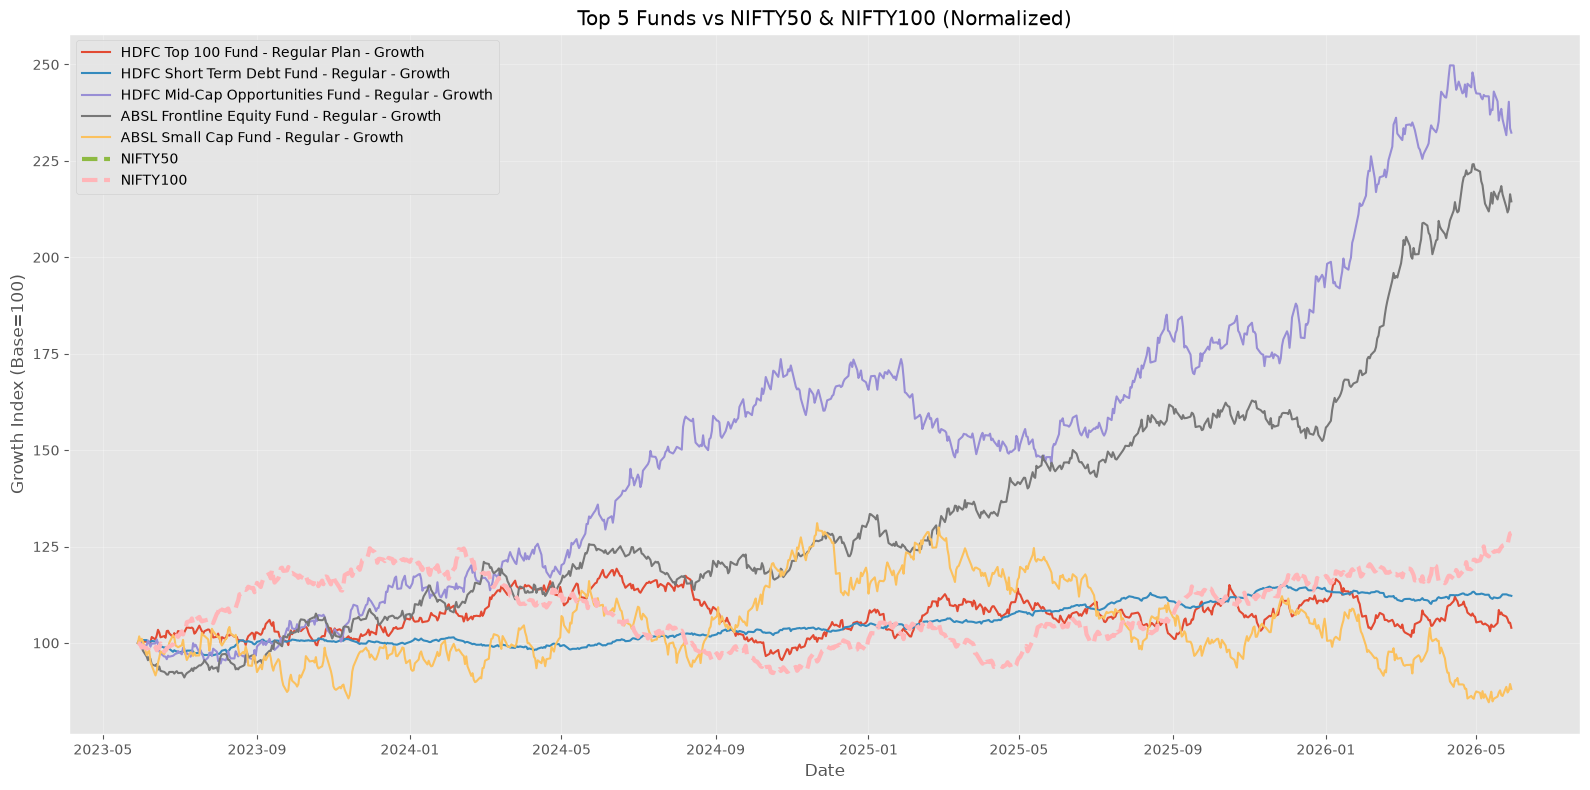

In [52]:
plt.figure(figsize=(16,8))
#top funds
for fund in top5_funds:

    temp = top_nav[

        top_nav["amfi_code"]==fund

    ]

    name = funds.loc[

        funds["amfi_code"]==fund,

        "scheme_name"

    ].iloc[0]

    plt.plot(

        temp["date"],

        temp["normalized_nav"],

        label=name,

        linewidth=1.5

    )
#benchmarks
for index in [

    "NIFTY50",

    "NIFTY100"

]:

    temp = bench[

        bench["index_name"]==index

    ]

    plt.plot(

        temp["date"],

        temp["normalized"],

        linewidth=3,

        linestyle="--",

        label=index

    )
plt.title(

    "Top 5 Funds vs NIFTY50 & NIFTY100 (Normalized)"

)

plt.xlabel("Date")

plt.ylabel("Growth Index (Base=100)")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(CHARTS/"benchmark"/"benchmark_chart.png",dpi=300)

plt.show()

# Insights

• All funds and benchmark indices were normalized to a base value of 100, allowing direct comparison of cumulative growth.

• HDFC Mid-Cap Opportunities Fund generated the highest cumulative return over the analysis period, substantially outperforming both NIFTY50 and NIFTY100.

• ABSL Frontline Equity Fund consistently remained above benchmark levels, indicating sustained long-term outperformance.

• HDFC Top 100 Fund closely tracked benchmark performance with comparatively lower volatility.

• ABSL Small Cap Fund exhibited the highest volatility and the largest deviation from benchmark returns, characteristic of actively managed small-cap funds.

• The benchmark indices displayed relatively steady long-term growth, providing an effective baseline for evaluating fund performance.

• The comparison demonstrates that selected actively managed funds generated positive excess returns over the benchmark during the three-year period.

In [54]:
#tracking error calculation
#Create benchmark returns
benchmark_return = benchmark[

    benchmark["index_name"]=="NIFTY100"

][

    [

        "date",

        "benchmark_return"

    ]

]
tracking = []
for fund in top5_funds:

    temp = nav[

        nav["amfi_code"]==fund

    ][

        [

            "date",

            "daily_return"

        ]

    ]

    merged = temp.merge(

        benchmark_return,

        on="date"

    ).dropna()

    tracking_error = (merged["daily_return"]-merged["benchmark_return"]).std()
    tracking.append({

    "amfi_code":fund,

    "tracking_error":tracking_error

    })
tracking_error = pd.DataFrame(tracking)
tracking_error = tracking_error.merge(

    funds[

        [

            "amfi_code",

            "scheme_name"

        ]

    ],

    on="amfi_code"

)
tracking_error["tracking_error"] = (

    tracking_error["tracking_error"]

    .round(6)

)
tracking_error

,amfi_code,tracking_error,scheme_name
0,100016,0.012554,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.008475,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.014407,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.012139,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.018402,ABSL Small Cap Fund - Regular - Growth


# Tracking Error Analysis

Tracking Error measures the standard deviation of the difference between a fund's daily returns and benchmark returns.

| Fund | Tracking Error |
|------|---------------:|
| HDFC Short Term Debt Fund | 0.008475 |
| ABSL Frontline Equity Fund | 0.012139 |
| HDFC Top 100 Fund | 0.012554 |
| HDFC Mid-Cap Opportunities Fund | 0.014407 |
| ABSL Small Cap Fund | 0.018402 |

**Observations**

- HDFC Short Term Debt Fund recorded the lowest tracking error, indicating the closest alignment with benchmark movements.
- ABSL Small Cap Fund showed the highest tracking error, reflecting greater active management and increased return variability.
- Moderate tracking error combined with benchmark outperformance suggests effective active portfolio management rather than excessive risk.

# Day 4 – Key Findings

1. Daily return analysis enabled computation of all major risk and performance metrics for each mutual fund.
2. CAGR analysis identified funds with strong long-term wealth creation potential over 1-year, 3-year and 5-year periods.
3. Risk-adjusted metrics such as Sharpe and Sortino Ratios highlighted funds delivering superior returns relative to total and downside risk.
4. Alpha and Beta analysis measured each fund's excess return and market sensitivity against the NIFTY100 benchmark.
5. Maximum Drawdown quantified the largest historical decline experienced by each fund, helping assess downside risk.
6. The composite Fund Scorecard combined return, risk and cost metrics to rank funds objectively on a 0–100 scale.
7. Benchmark comparison demonstrated that several actively managed funds outperformed both NIFTY50 and NIFTY100 over the analysis period.
8. Tracking Error analysis showed varying levels of benchmark deviation, reflecting differences in active portfolio management strategies.
9. Mid-cap and diversified equity funds generally achieved higher long-term growth but exhibited greater volatility.
10. The overall analysis indicates that selecting mutual funds based on multiple performance indicators provides a more reliable investment assessment than relying solely on historical returns.